In [1]:
import pandas as pd
import matplotlib.pyplot as plt

master = pd.read_csv("../data/processed/airbnb_master.csv")

print(master.shape)
master.head()

Matplotlib is building the font cache; this may take a moment.


(96871, 83)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,available_days,booked_days,total_calendar_days,avg_calendar_price,occupancy_rate,estimated_revenue
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,1,0,0.30,13913,331,34,365,NaN,9.315068,NaN
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,0,0,0.51,15400,199,166,365,NaN,45.479452,NaN
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,0,0,0.32,17402,80,285,365,NaN,78.082192,NaN
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,0,0,0.53,24328,294,71,365,NaN,19.452055,NaN
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,0,0,0.09,36274,323,42,365,NaN,11.506849,NaN


In [2]:
master[
    [
        "price",
        "bedrooms",
        "bathrooms",
        "review_scores_rating",
        "availability_365",
        "occupancy_rate",
        "estimated_revenue"
    ]
].describe()

,price,bedrooms,bathrooms,review_scores_rating,availability_365,occupancy_rate,estimated_revenue
count,6.196300e+04,84096.000000,62025.00000,72749.000000,96871.000000,96871.000000,0.0
mean,2.299170e+02,1.607092,1.35555,4.684719,144.927429,60.280249,NaN
std,4.437589e+03,1.040425,0.72077,0.494191,141.808279,38.851356,NaN
min,7.000000e+00,0.000000,0.00000,0.000000,0.000000,0.000000,NaN
25%,7.700000e+01,1.000000,1.00000,4.580000,0.000000,21.095890,NaN
50%,1.350000e+02,1.000000,1.00000,4.830000,96.000000,73.698630,NaN
75%,2.210000e+02,2.000000,1.50000,5.000000,288.000000,100.000000,NaN
max,1.085147e+06,50.000000,26.00000,5.000000,365.000000,100.000000,NaN


In [3]:
room_counts = master["room_type"].value_counts()
room_counts

room_type
Entire home/apt    62907
Private room       33643
Shared room          212
Hotel room           109
Name: count, dtype: int64

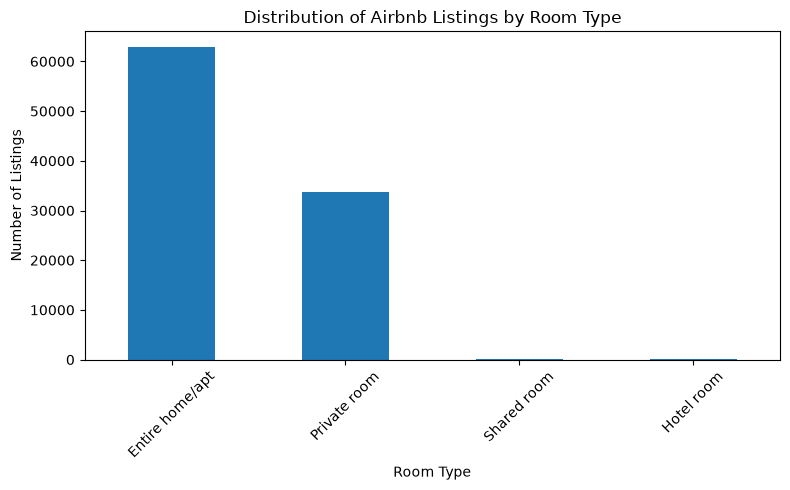

In [4]:
room_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
master["neighbourhood_cleansed"].value_counts().head(15)

neighbourhood_cleansed
Westminster               11385
Tower Hamlets              7469
Camden                     6551
Kensington and Chelsea     6401
Hackney                    6359
Southwark                  5475
Lambeth                    5190
Islington                  5036
Wandsworth                 4965
Hammersmith and Fulham     4157
Brent                      3019
Lewisham                   2680
Haringey                   2598
Barnet                     2529
Newham                     2522
Name: count, dtype: int64

In [6]:
master.groupby(
    "neighbourhood_cleansed"
)["price"].mean().sort_values(
    ascending=False
).head(10)

neighbourhood_cleansed
Tower Hamlets             430.906199
City of London            354.389908
Lambeth                   345.710741
Westminster               342.139405
Kensington and Chelsea    336.072148
Islington                 217.546807
Camden                    216.511547
Hammersmith and Fulham    199.188085
Wandsworth                198.431607
Richmond upon Thames      184.270936
Name: price, dtype: float64

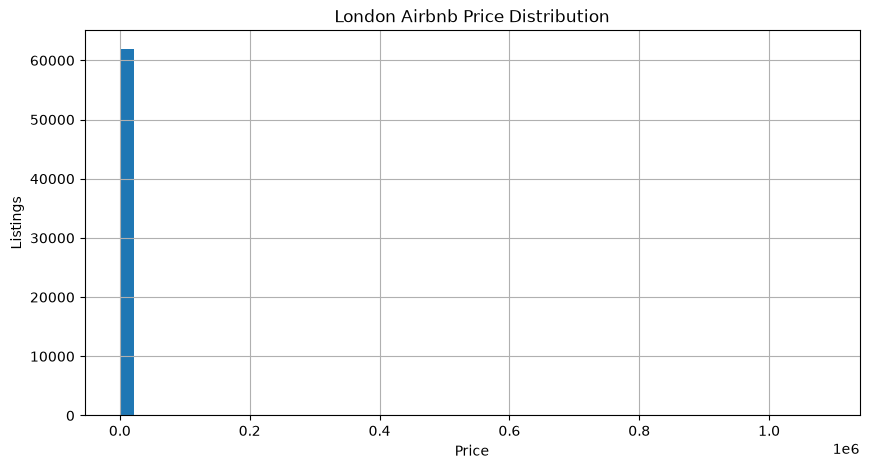

In [7]:
master["price"].hist(
    bins=50,
    figsize=(10,5)
)

plt.title("London Airbnb Price Distribution")
plt.xlabel("Price")
plt.ylabel("Listings")

plt.show()

In [8]:
master["price"].nlargest(20)

83405    1085147.0
10228      74100.0
77023      66189.0
54442      65000.0
57204      58000.0
75312      58000.0
9489       53588.0
38591      50000.0
51162      50000.0
63728      30812.0
69658      30000.0
69137      28000.0
60054      25106.0
54422      22824.0
67625      20000.0
69489      15143.0
65735      15000.0
53628      12000.0
77359      12000.0
81617      11952.0
Name: price, dtype: float64

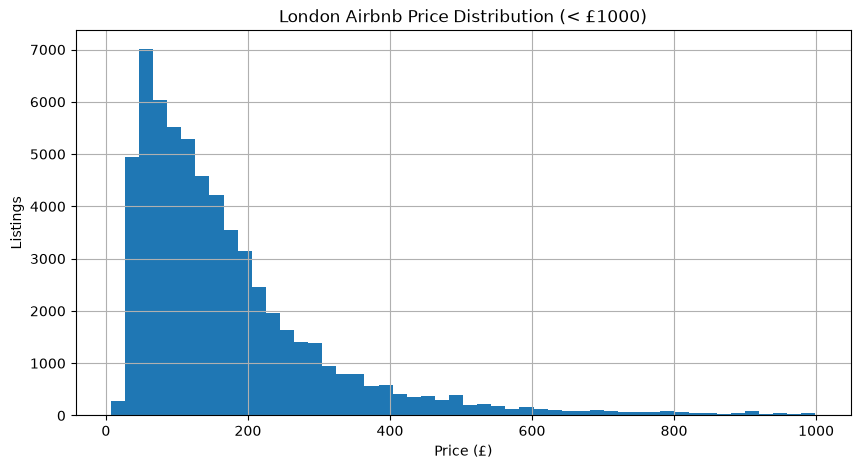

In [9]:
master[
    master["price"] < 1000
]["price"].hist(
    bins=50,
    figsize=(10,5)
)

plt.title(
    "London Airbnb Price Distribution (< £1000)"
)

plt.xlabel("Price (£)")
plt.ylabel("Listings")

plt.show()

In [10]:
master["price"].quantile(
    [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

0.25      77.0
0.50     135.0
0.75     221.0
0.90     360.0
0.95     500.0
0.99    1100.0
Name: price, dtype: float64

In [11]:
master["price"].describe(
    percentiles=[0.90,0.95,0.99]
)

count    6.196300e+04
mean     2.299170e+02
std      4.437589e+03
min      7.000000e+00
90%      3.600000e+02
95%      5.000000e+02
99%      1.100000e+03
max      1.085147e+06
Name: price, dtype: float64

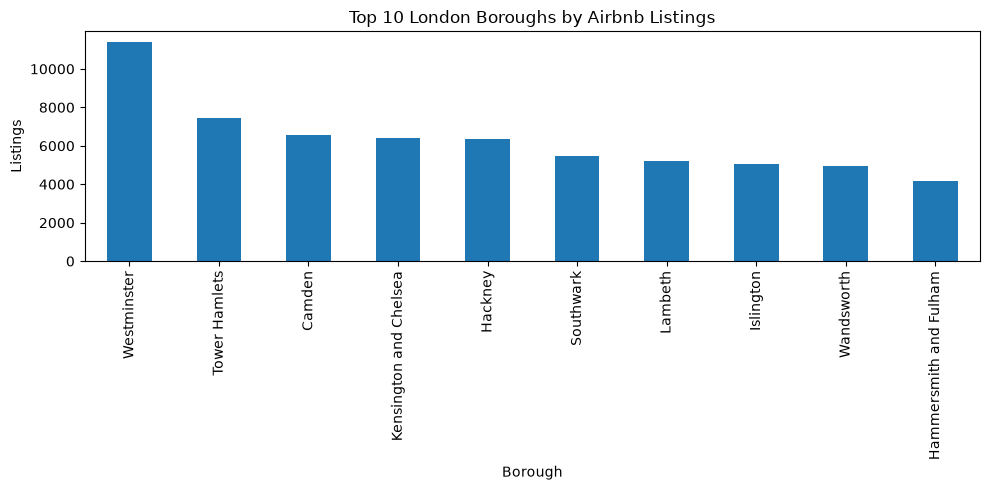

In [12]:
top_boroughs = (
    master["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_boroughs.plot(
    kind="bar"
)

plt.title("Top 10 London Boroughs by Airbnb Listings")
plt.xlabel("Borough")
plt.ylabel("Listings")

plt.tight_layout()

plt.show()

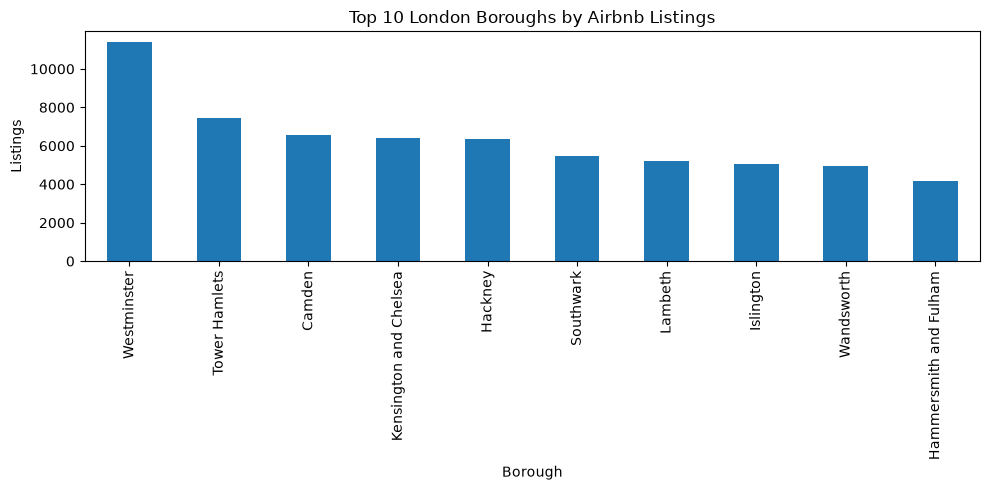

In [13]:
plt.figure(figsize=(10,5))

top_boroughs.plot(
    kind="bar"
)

plt.title("Top 10 London Boroughs by Airbnb Listings")
plt.xlabel("Borough")
plt.ylabel("Listings")

plt.tight_layout()

plt.savefig(
    "../reports/top10_boroughs_listings.png"
)

plt.show()

In [14]:
borough_price = (
    master.groupby(
        "neighbourhood_cleansed"
    )["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

borough_price

neighbourhood_cleansed
Tower Hamlets             430.906199
City of London            354.389908
Lambeth                   345.710741
Westminster               342.139405
Kensington and Chelsea    336.072148
Islington                 217.546807
Camden                    216.511547
Hammersmith and Fulham    199.188085
Wandsworth                198.431607
Richmond upon Thames      184.270936
Name: price, dtype: float64

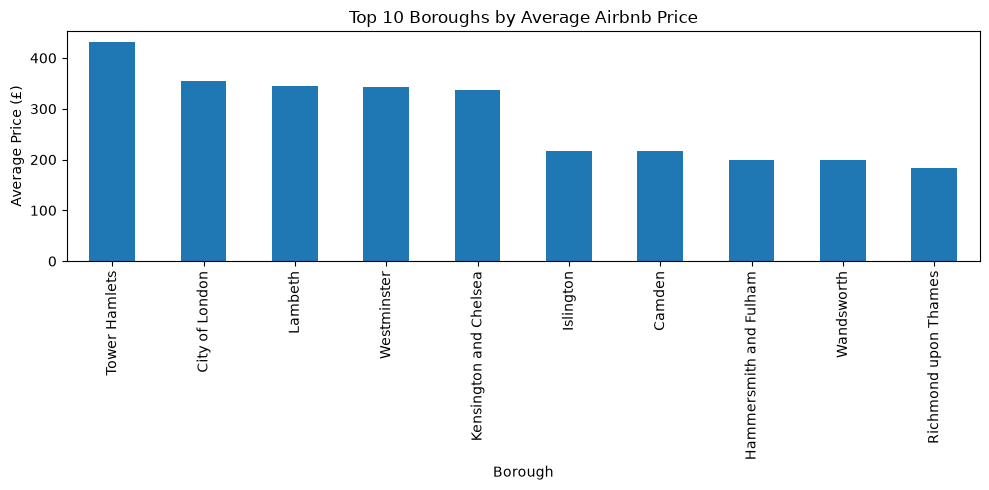

In [15]:
plt.figure(figsize=(10,5))

borough_price.plot(
    kind="bar"
)

plt.title("Top 10 Boroughs by Average Airbnb Price")
plt.xlabel("Borough")
plt.ylabel("Average Price (£)")

plt.tight_layout()

plt.savefig(
    "../reports/top10_boroughs_price.png"
)

plt.show()

In [16]:
master["occupancy_rate"].describe()

count    96871.000000
mean        60.280249
std         38.851356
min          0.000000
25%         21.095890
50%         73.698630
75%        100.000000
max        100.000000
Name: occupancy_rate, dtype: float64

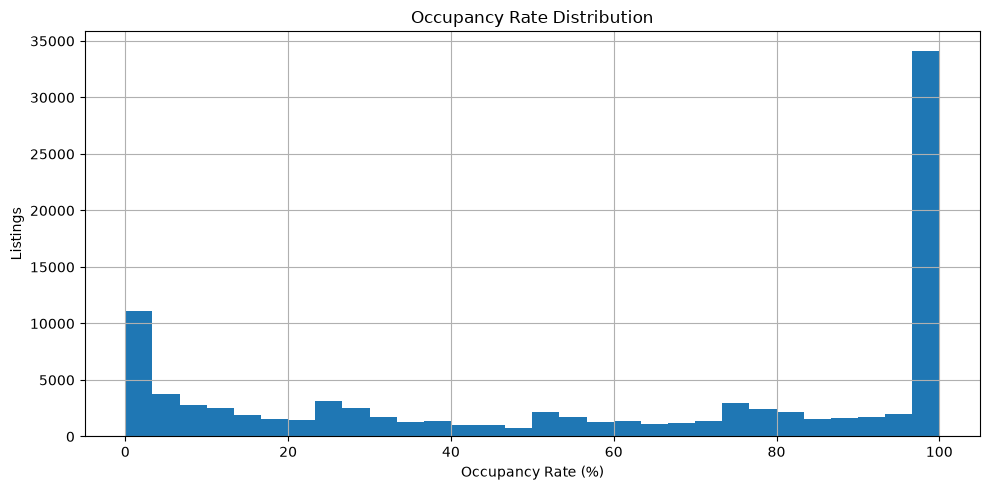

In [17]:
plt.figure(figsize=(10,5))

master["occupancy_rate"].hist(
    bins=30
)

plt.title("Occupancy Rate Distribution")
plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Listings")

plt.tight_layout()

plt.savefig(
    "../reports/occupancy_distribution.png"
)

plt.show()

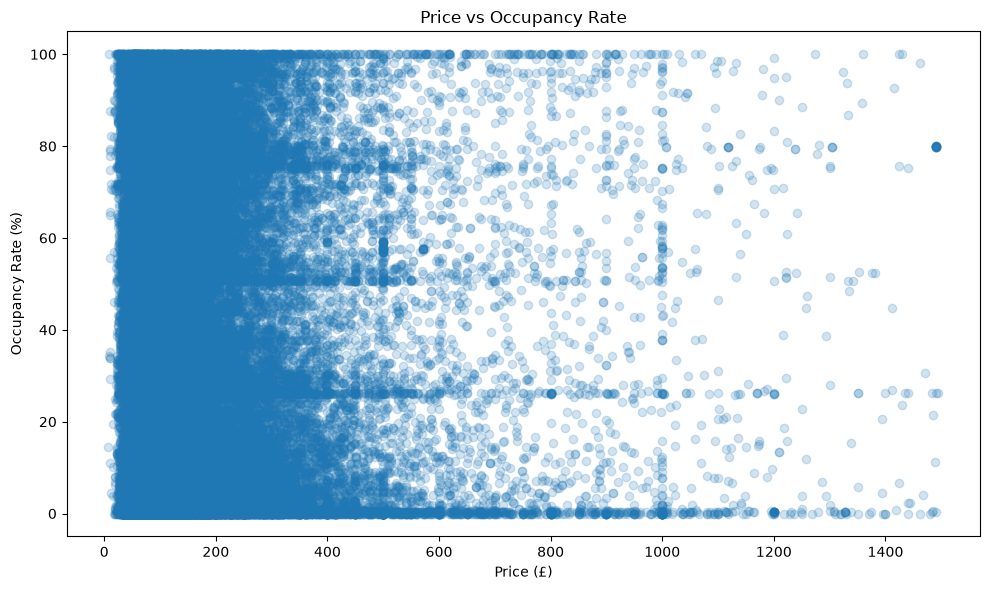

In [18]:
sample = master[
    (master["price"] < 1500)
]

plt.figure(figsize=(10,6))

plt.scatter(
    sample["price"],
    sample["occupancy_rate"],
    alpha=0.2
)

plt.title(
    "Price vs Occupancy Rate"
)

plt.xlabel("Price (£)")
plt.ylabel("Occupancy Rate (%)")

plt.tight_layout()

plt.savefig(
    "../reports/price_vs_occupancy.png"
)

plt.show()

In [19]:
master[
    ["price","occupancy_rate"]
].corr()

,price,occupancy_rate
price,1.000000,-0.010286
occupancy_rate,-0.010286,1.000000


In [20]:
master.columns[
    master.columns.str.contains(
        "revenue",
        case=False
    )
]

Index(['estimated_revenue_l365d', 'estimated_revenue'], dtype='str')

In [21]:
master[
    [
        "estimated_revenue_l365d",
        "estimated_revenue"
    ]
].isnull().sum()

estimated_revenue_l365d    34908
estimated_revenue          96871
dtype: int64

In [22]:
master[
    [
        "estimated_revenue_l365d",
        "estimated_revenue"
    ]
].head(20)

,estimated_revenue_l365d,estimated_revenue
0,6440.0,NaN
1,1341.0,NaN
2,0.0,NaN
3,NaN,NaN
4,12600.0,NaN
5,15400.0,NaN
6,22950.0,NaN
7,0.0,NaN
8,0.0,NaN
9,7203.0,NaN


In [23]:
master[
    [
        "estimated_revenue_l365d",
        "estimated_revenue"
    ]
].describe()

,estimated_revenue_l365d,estimated_revenue
count,6.196300e+04,0.0
mean,1.047348e+04,NaN
std,6.612429e+04,NaN
min,0.000000e+00,NaN
25%,0.000000e+00,NaN
50%,2.968000e+03,NaN
75%,1.225000e+04,NaN
max,1.015000e+07,NaN


In [24]:
top_revenue = (
    master.groupby(
        "neighbourhood_cleansed"
    )["estimated_revenue_l365d"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_revenue

neighbourhood_cleansed
Lambeth                   21777.186104
Westminster               16808.500651
Kensington and Chelsea    15366.722525
City of London            13741.300459
Camden                    13074.275289
Islington                 11709.915094
Southwark                 10618.879117
Hammersmith and Fulham    10531.262271
Tower Hamlets              9679.057544
Richmond upon Thames       8509.241379
Name: estimated_revenue_l365d, dtype: float64

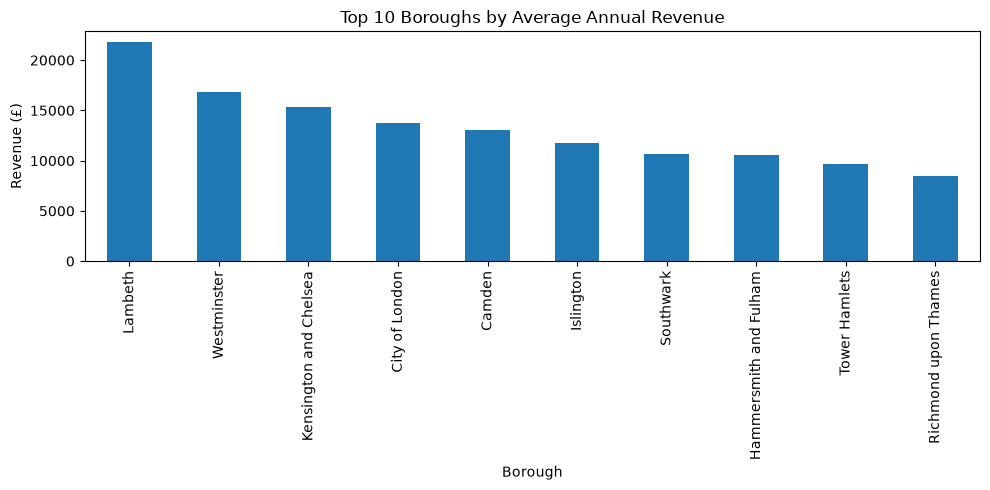

In [29]:
plt.figure(figsize=(10,5))

top_revenue.plot(
    kind="bar"
)

plt.title(
    "Top 10 Boroughs by Average Annual Revenue"
)

plt.xlabel("Borough")
plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.savefig(
    "../reports/top10_boroughs_revenue.png"
)

plt.show()

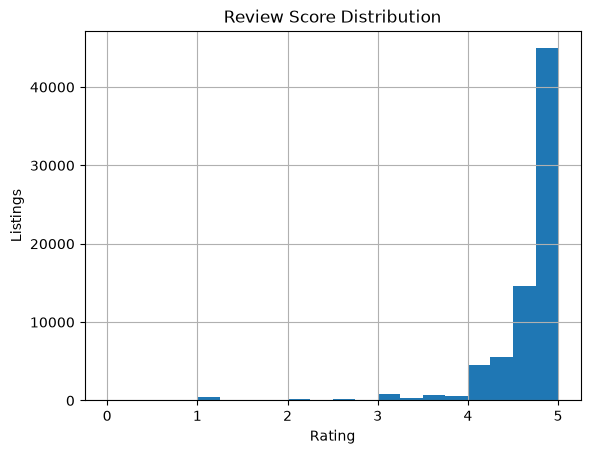

In [28]:
master["review_scores_rating"].hist(bins=20)

plt.title("Review Score Distribution")
plt.xlabel("Rating")
plt.ylabel("Listings")

plt.savefig("../reports/review_score_distribution.png")
plt.show()

In [27]:
import pandas as pd

master = pd.read_csv("../data/processed/airbnb_master.csv")

print(master.shape)

(96871, 89)
